In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()

if not (BASE_DIR / "data").exists():
    BASE_DIR = Path("..").resolve()

DATA_PATH = BASE_DIR / "data" / "processed" / "final_phishing_dataset.csv"
FEATURE_PATH = BASE_DIR / "models" / "ml_features_dataset.csv"
RESULTS_PATH = BASE_DIR / "models" / "ml_model_results.csv"

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

print("Base directory:", BASE_DIR)

Base directory: D:\phishing-detection


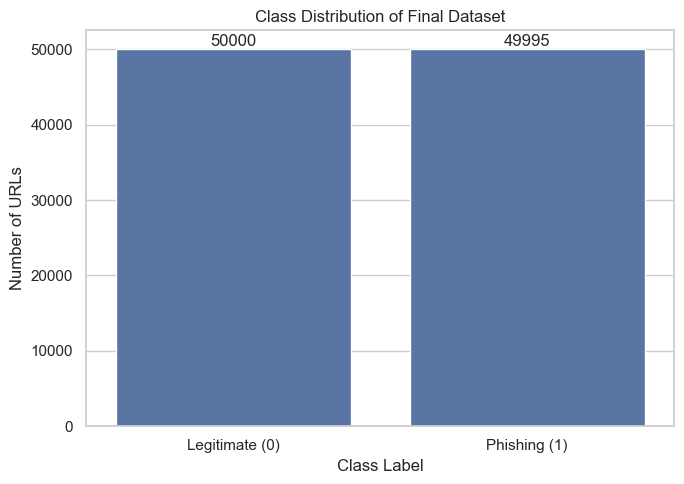

In [3]:
df = pd.read_csv(DATA_PATH)

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="label"
)

plt.title("Class Distribution of Final Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of URLs")
plt.xticks([0, 1], ["Legitimate (0)", "Phishing (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=300)
plt.show()

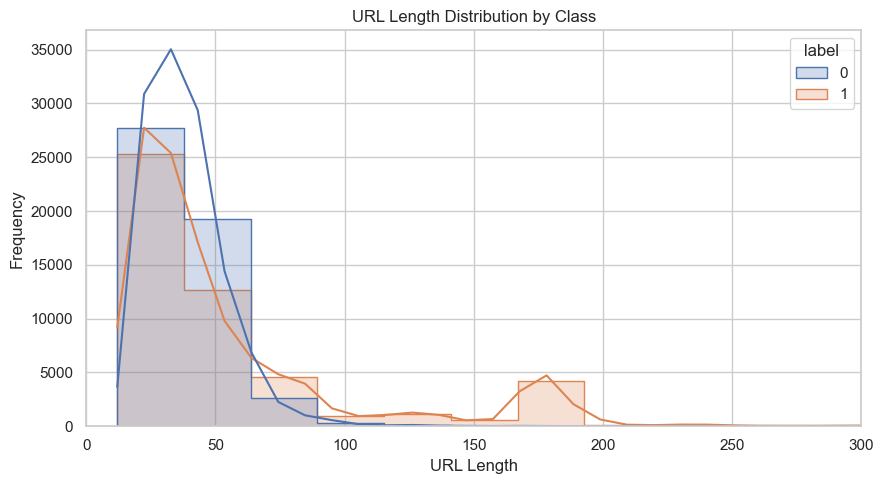

In [4]:
df["url_length"] = df["url"].astype(str).apply(len)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="url_length",
    hue="label",
    bins=80,
    kde=True,
    element="step"
)

plt.title("URL Length Distribution by Class")
plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.xlim(0, 300)

plt.tight_layout()
plt.savefig(FIG_DIR / "url_length_distribution.png", dpi=300)
plt.show()

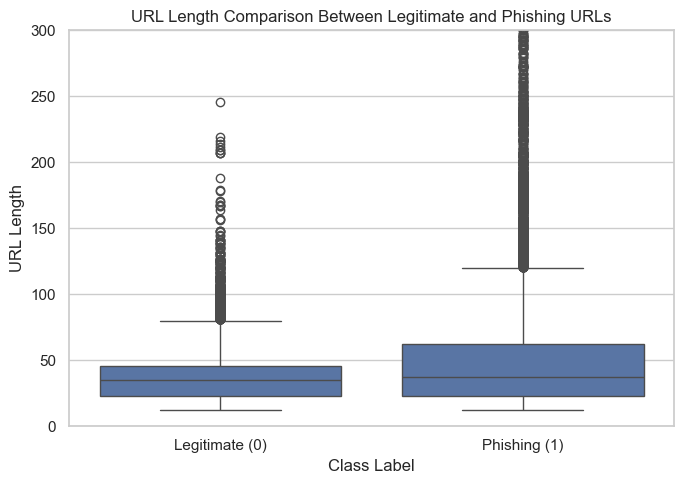

In [5]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="label",
    y="url_length"
)

plt.title("URL Length Comparison Between Legitimate and Phishing URLs")
plt.xlabel("Class Label")
plt.ylabel("URL Length")
plt.xticks([0, 1], ["Legitimate (0)", "Phishing (1)"])
plt.ylim(0, 300)

plt.tight_layout()
plt.savefig(FIG_DIR / "url_length_boxplot.png", dpi=300)
plt.show()

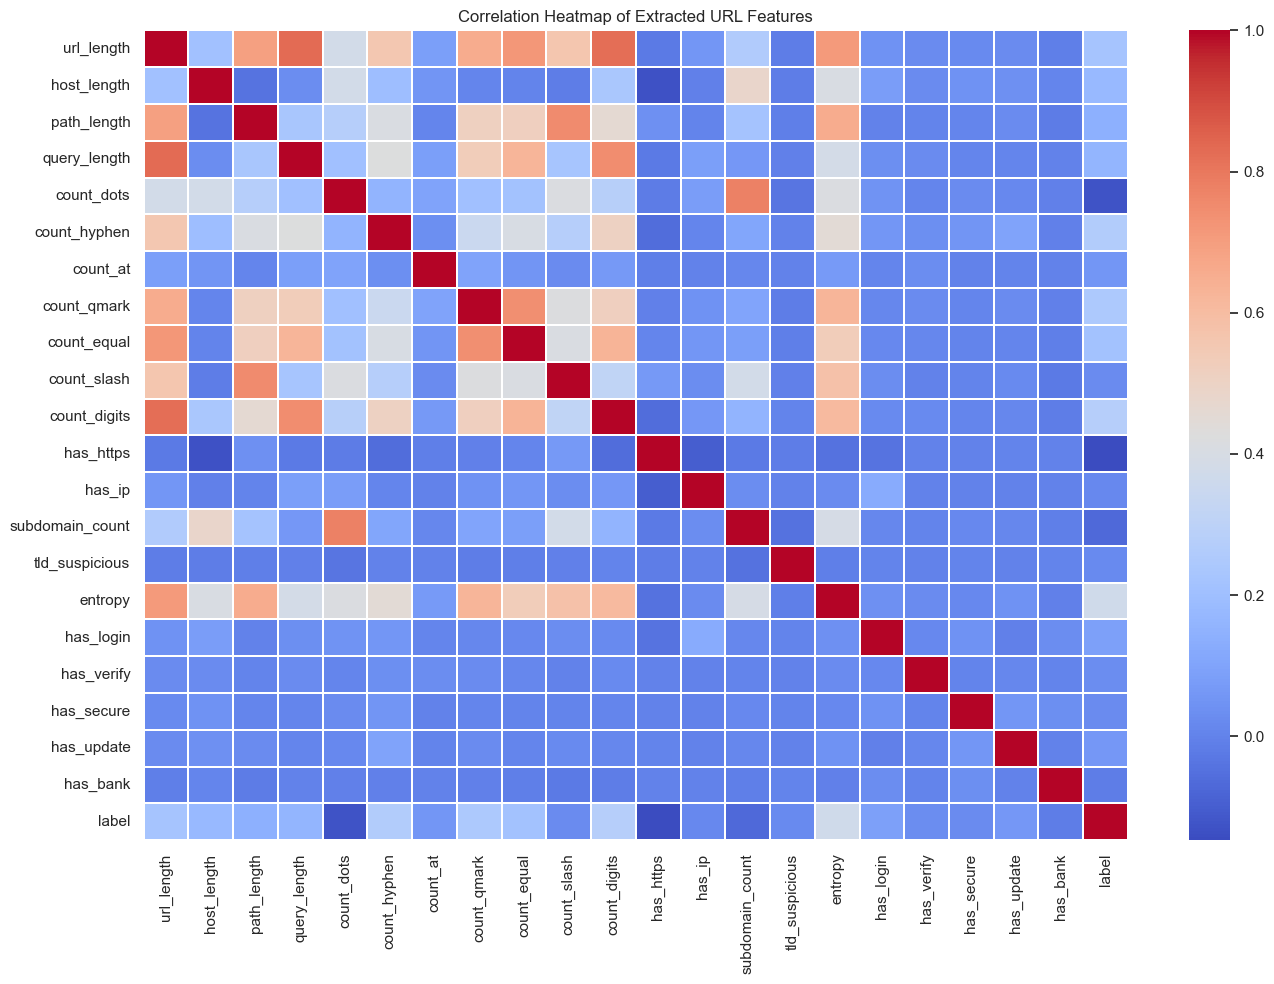

In [6]:
features_df = pd.read_csv(FEATURE_PATH)

plt.figure(figsize=(14, 10))

corr = features_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.3
)

plt.title("Correlation Heatmap of Extracted URL Features")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=300)
plt.show()

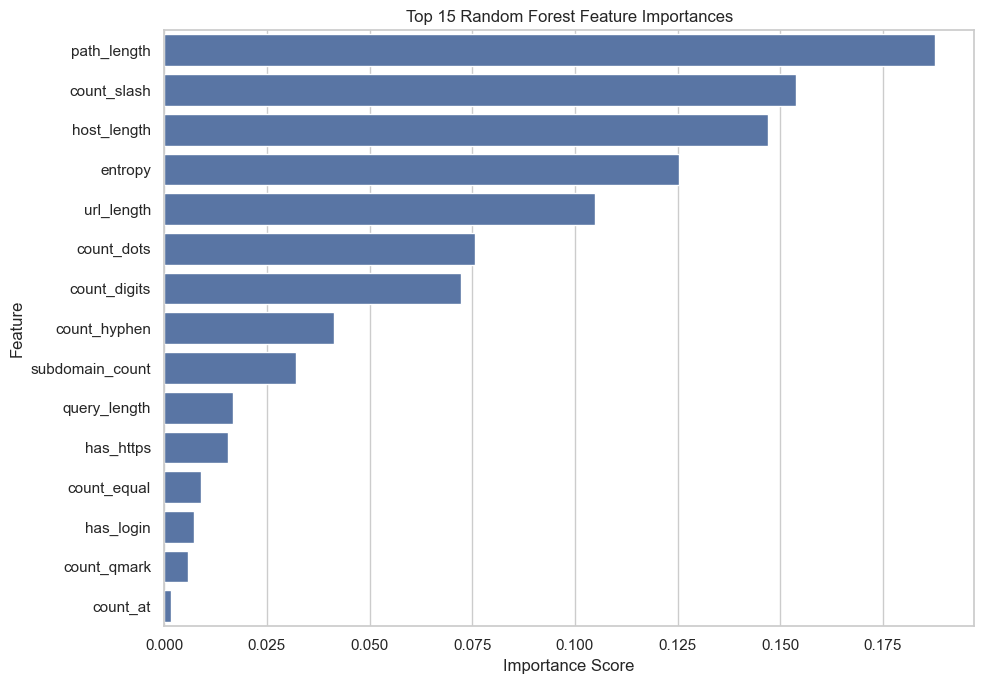

In [7]:
features_df = pd.read_csv(FEATURE_PATH)

X = features_df.drop(columns=["label"])

with open(BASE_DIR / "models" / "random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(FIG_DIR / "random_forest_feature_importance.png", dpi=300)
plt.show()

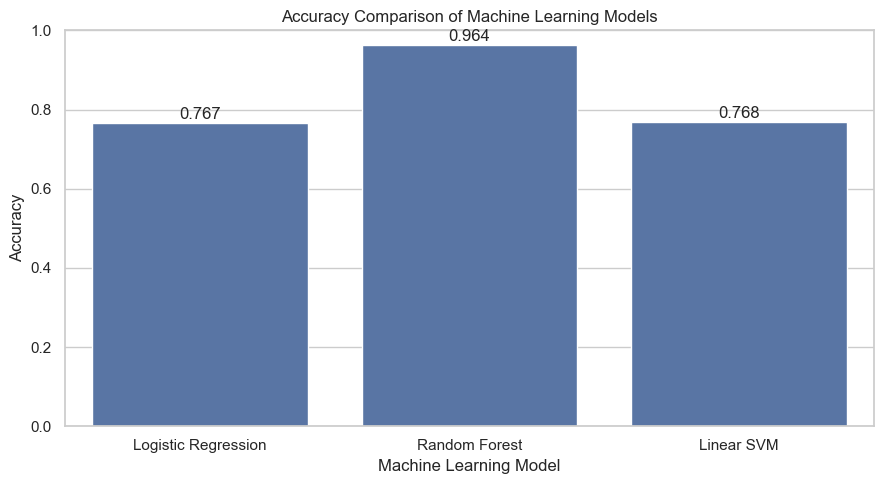

In [8]:
results_df = pd.read_csv(RESULTS_PATH)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for index, row in results_df.iterrows():
    plt.text(index, row["Accuracy"] + 0.01, f"{row['Accuracy']:.3f}", ha="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "ml_accuracy_comparison.png", dpi=300)
plt.show()

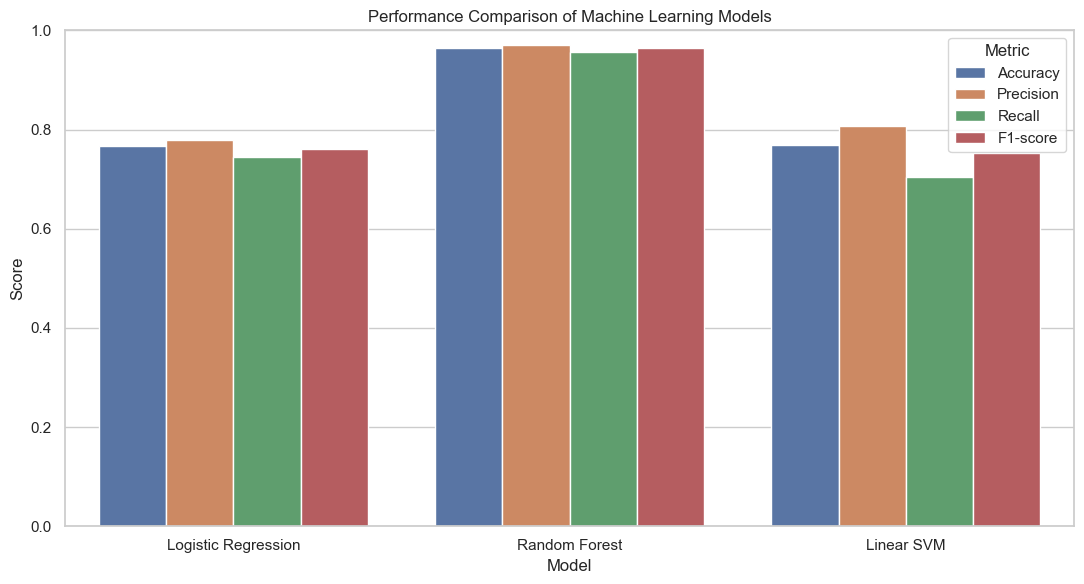

In [9]:
results_df = pd.read_csv(RESULTS_PATH)

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / "ml_metrics_comparison.png", dpi=300)
plt.show()

In [10]:
ml_results = pd.read_csv(RESULTS_PATH)

deep_result = pd.DataFrame([{
    "Model": "CNN + BiGRU + Attention",
    "Accuracy": 0.9897,
    "Precision": 0.99,
    "Recall": 0.99,
    "F1-score": 0.99
}])

all_results = pd.concat([ml_results, deep_result], ignore_index=True)

all_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.766538,0.778242,0.745475,0.761506
1,Random Forest,0.964048,0.970779,0.956896,0.963787
2,Linear SVM,0.768288,0.808015,0.703770,0.752298
3,CNN + BiGRU + Attention,0.989700,0.990000,0.990000,0.990000


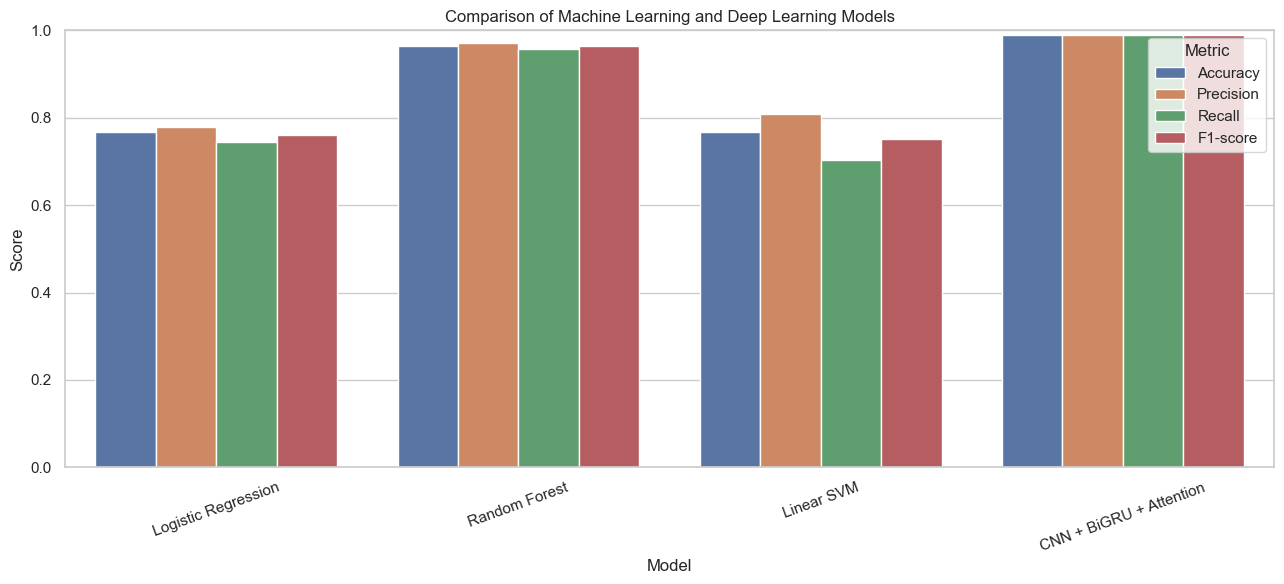

In [11]:
all_results_melted = all_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=all_results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Machine Learning and Deep Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_vs_deep_learning_comparison.png", dpi=300)
plt.show()

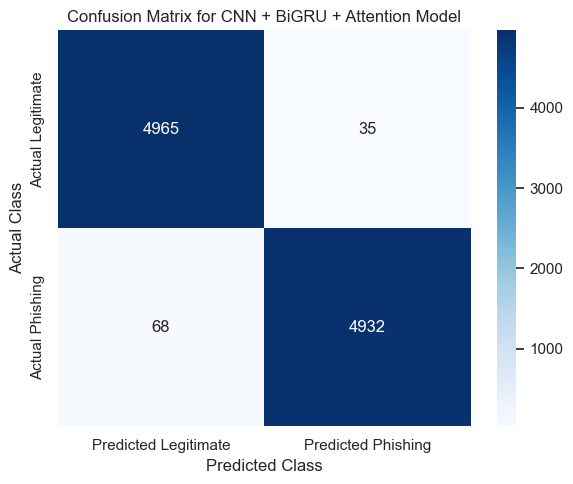

In [12]:
from sklearn.metrics import confusion_matrix

deep_cm = np.array([
    [4965, 35],
    [68, 4932]
])

plt.figure(figsize=(6, 5))

sns.heatmap(
    deep_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legitimate", "Predicted Phishing"],
    yticklabels=["Actual Legitimate", "Actual Phishing"]
)

plt.title("Confusion Matrix for CNN + BiGRU + Attention Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig(FIG_DIR / "deep_learning_confusion_matrix.png", dpi=300)
plt.show()

In [14]:
import pandas as pd
import pickle
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

BASE_DIR = Path.cwd()

if not (BASE_DIR / "data").exists():
    BASE_DIR = Path("..").resolve()

FEATURE_PATH = BASE_DIR / "models" / "ml_features_dataset.csv"
RF_MODEL_PATH = BASE_DIR / "models" / "random_forest.pkl"

features_df = pd.read_csv(FEATURE_PATH)

X = features_df.drop(columns=["label"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

with open(RF_MODEL_PATH, "rb") as f:
    rf_model = pickle.load(f)

rf_pred = rf_model.predict(X_test)

print("Ready.")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("rf_pred shape:", rf_pred.shape)

Ready.
X_test shape: (19999, 21)
y_test shape: (19999,)
rf_pred shape: (19999,)


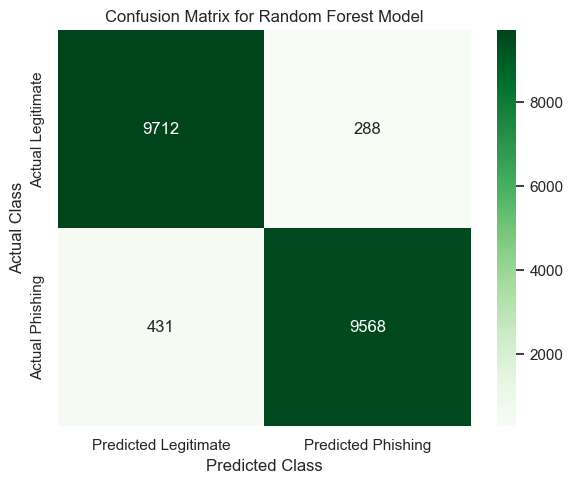

In [15]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted Legitimate", "Predicted Phishing"],
    yticklabels=["Actual Legitimate", "Actual Phishing"]
)

plt.title("Confusion Matrix for Random Forest Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig(FIG_DIR / "random_forest_confusion_matrix.png", dpi=300)
plt.show()

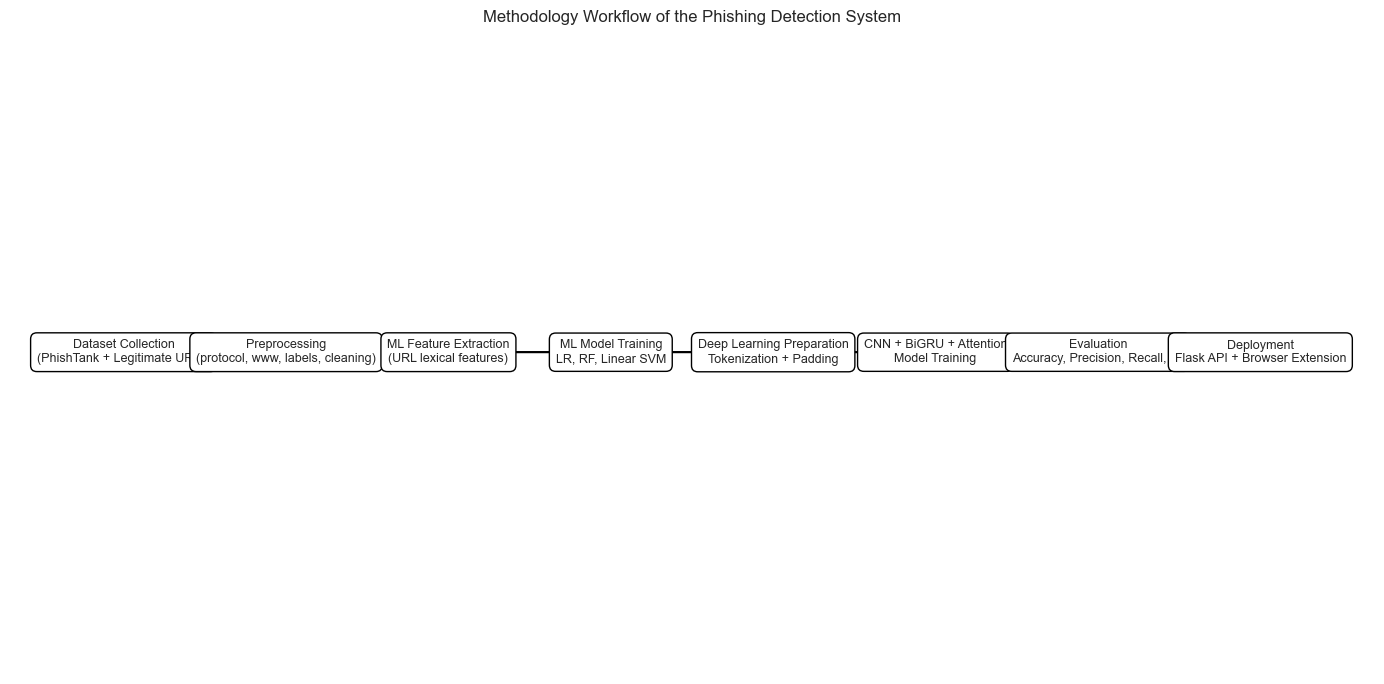

In [16]:
import matplotlib.pyplot as plt

steps = [
    "Dataset Collection\n(PhishTank + Legitimate URLs)",
    "Preprocessing\n(protocol, www, labels, cleaning)",
    "ML Feature Extraction\n(URL lexical features)",
    "ML Model Training\nLR, RF, Linear SVM",
    "Deep Learning Preparation\nTokenization + Padding",
    "CNN + BiGRU + Attention\nModel Training",
    "Evaluation\nAccuracy, Precision, Recall, F1",
    "Deployment\nFlask API + Browser Extension"
]

plt.figure(figsize=(14, 7))

for i, step in enumerate(steps):
    plt.text(
        i,
        0,
        step,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white"),
        fontsize=9
    )
    
    if i < len(steps) - 1:
        plt.arrow(
            i + 0.35,
            0,
            0.3,
            0,
            head_width=0.05,
            head_length=0.08,
            fc="black",
            ec="black"
        )

plt.xlim(-0.7, len(steps) - 0.3)
plt.ylim(-0.5, 0.5)
plt.axis("off")
plt.title("Methodology Workflow of the Phishing Detection System")

plt.tight_layout()
plt.savefig(FIG_DIR / "methodology_workflow.png", dpi=300)
plt.show()